# QC of input reads

In [1]:
library(tidyverse)
library(ggplot2)

Warning message:
“package ‘lubridate’ was built under R version 4.4.2”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


In [3]:
source("../scripts/02_plot_read_stats.R")

Warning message:
“package ‘KernSmooth’ was built under R version 4.4.2”
KernSmooth 2.23 loaded
Copyright M. P. Wand 1997-2009



Compare our first two raw datasets (before filtering / merging) to published data


In [4]:
plot_read_stats(
  stats_files = c(
    "/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/assembly/input_qc/published/published.UL/read_stats.txt",
    "/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/assembly/input_qc/run_04399/run_04399.UL/read_stats.txt",
    "/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/assembly/input_qc/run_04400/run_04400.UL/read_stats.txt"
  ),
  out_prefix = "UL_comparison"
)

ERROR: Error in plot_read_stats(stats_files = c("/mnt/storage3b/projects/no_ngsd/ahthapp1_T2T_ONT/assembly/input_qc/published/published.UL/read_stats.txt", : could not find function "plot_read_stats"


In [9]:
dt <- read_csv("../../doc/run_reports/run_summary.csv")
dt_ul <- dt %>% filter(str_detect(kit_type, "SQK-ULK114"))

Rows: 42 Columns: 36
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (12): flow_cell_id, run_status, run_status_context, device_type, device...
dbl  (15): estimated_n50, experiment_name, estimated_bases, data_produced_by...
lgl   (7): run_complete, alignment_enabled, barcoding_enabled, basecalling_e...
dttm  (2): run_start_time, run_end_time

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


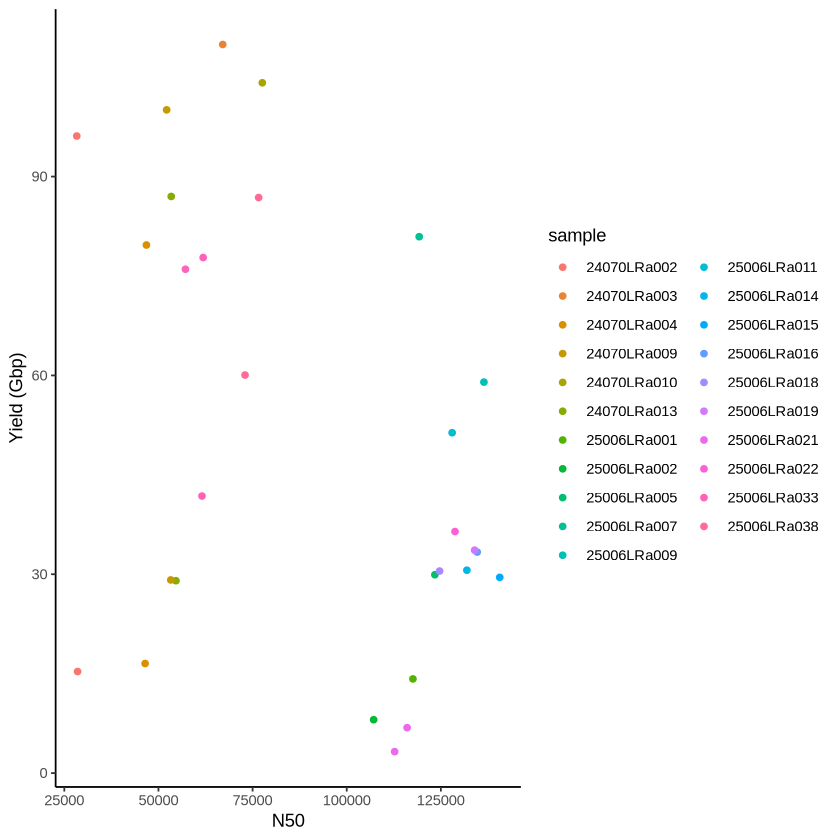

In [33]:
p_len_n50 <- ggplot(dt_ul, aes(x = estimated_n50, y = estimated_bases / 1e9, colour = str_split(sample_id, "_", simplify = TRUE)[, 1])) +
    geom_point() +
    theme_classic() +
    labs(x = "N50", y = "Yield (Gbp)", colour = "sample") +
    theme(legend.position = "right", legend.box = "vertical")
p_len_n50